In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_ROOT = Path("/work3/s252608/DL_project/data/output/model")

histories = []

for history_file in MODEL_ROOT.rglob("history_seed*.csv"):

    parts = history_file.parts

    representation = parts[-4]
    target_mode = parts[-3]
    model_type = parts[-2]

    df = pd.read_csv(history_file)

    df["representation"] = representation
    df["target_mode"] = target_mode
    df["model_type"] = model_type

    histories.append(df)

history = pd.concat(histories, ignore_index=True)

history.head()

,epoch,model_type,train_loss,val_loss,representation,target_mode
0,1,mse,1.389768,0.974385,vae_beta0p1,absolute
1,2,mse,0.946336,0.898167,vae_beta0p1,absolute
2,3,mse,0.889468,0.870600,vae_beta0p1,absolute
3,4,mse,0.858630,0.846075,vae_beta0p1,absolute
4,5,mse,0.838903,0.823348,vae_beta0p1,absolute


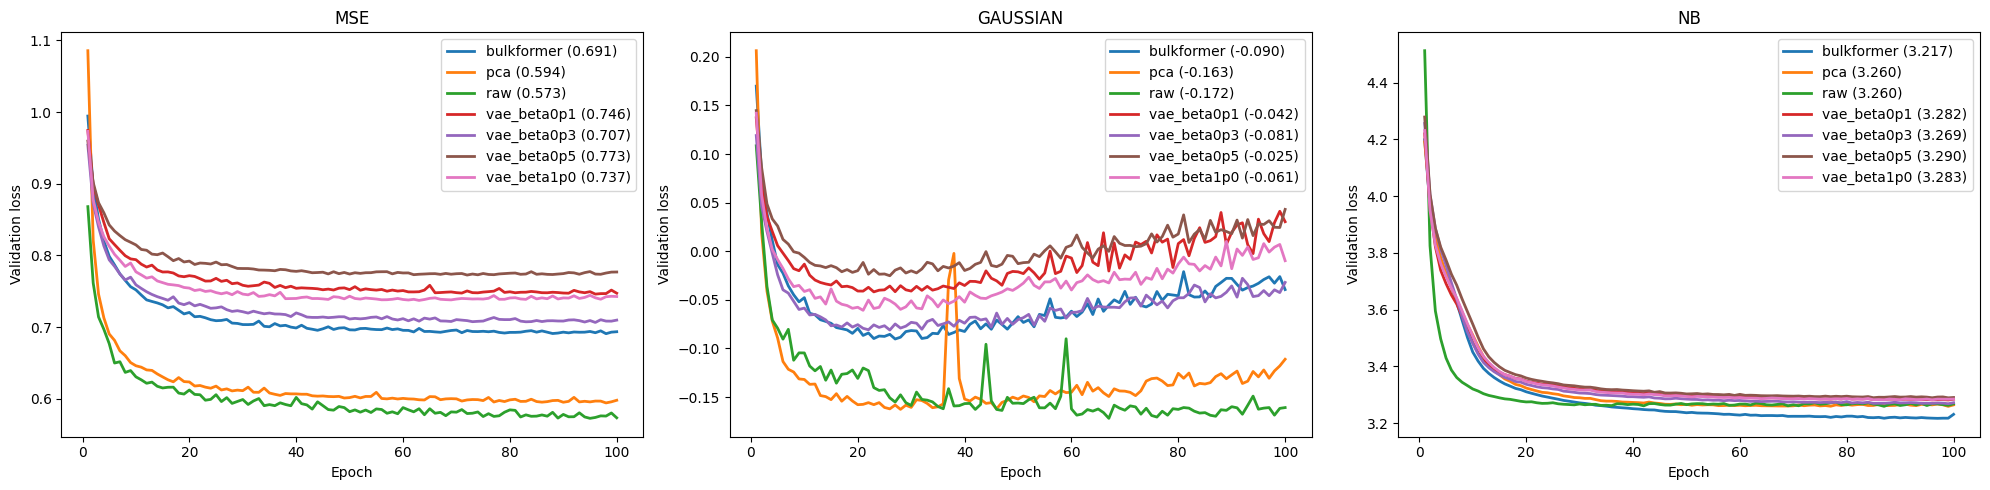

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)

model_order = ["mse", "gaussian", "nb"]

for ax, model_type in zip(axes, model_order):

    subset = history[
        history["model_type"] == model_type
    ]

    for repr_name, df_repr in subset.groupby("representation"):

        best_val = df_repr["val_loss"].min()

        ax.plot(
            df_repr["epoch"],
            df_repr["val_loss"],
            linewidth=2,
            label=f"{repr_name} ({best_val:.3f})"
        )

    ax.set_title(model_type.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss")
    ax.legend()

plt.tight_layout()
plt.show()